In [1]:
import math
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
from sklearn.model_selection import train_test_split
import importlib, training_engine
importlib.reload(training_engine)
from training_engine import train_model, plot_training_results, inspect_model

In [2]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)
device 

device(type='mps')

In [3]:
trainset = CIFAR10(
    root='../cifar10',
    train=True,
    download=False
)
X = trainset.data 
y = np.array(trainset.targets)
print(X.shape)
print(y.shape)
train_data , test_data, train_labels, test_labels = train_test_split(
    X,
    y,
    test_size=.1,
    shuffle=True 
)
train_tensors = torch.tensor(train_data).permute(0,3,1,2).float()/255.0
val_tensors = torch.tensor(test_data).permute(0,3,1,2).float()/255.0
train_labels_t = torch.tensor(train_labels)
val_labels_t = torch.tensor(test_labels)
trainset = TensorDataset(train_tensors, train_labels_t)
valset = TensorDataset(val_tensors,val_labels_t)
train_loader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(valset, batch_size=64, shuffle=False, num_workers=0)

(50000, 32, 32, 3)
(50000,)


In [ ]:
trainset = CIFAR10(
    root='../cifar10',
    train=True,
    download=False
)
X = trainset.data 
y = np.array(trainset.targets)
print(X.shape)
print(y.shape)
train_data , test_data, train_labels, test_labels = train_test_split(
    X,
    y,
    test_size=.1,
    shuffle=True 
)
train_tensors = torch.tensor(train_data).permute(0,3,1,2).float()/255.0
val_tensors = torch.tensor(test_data).permute(0,3,1,2).float()/255.0
train_labels_t = torch.tensor(train_labels)
val_labels_t = torch.tensor(test_labels)
trainset = TensorDataset(train_tensors, train_labels_t)
valset = TensorDataset(val_tensors,val_labels_t)
train_loader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(valset, batch_size=64, shuffle=False, num_workers=0)

### 1. Vanilla CNN

In [5]:
class cnnnet(nn.Module):
    def __init__(self):
        super().__init__()



        ### -------------- feature map layers -------------- ###
        # first convolution layer
        self.conv1  = nn.Conv2d(3,64,3,padding=1)
        self.bnorm1 = nn.BatchNorm2d(64) # input the number of channels in this layer
        # output size: (32+2*1-3)/1 + 1 = 32/2 = 16 (/2 b/c maxpool)

        # second convolution layer
        self.conv2  = nn.Conv2d(64,128,3)
        self.bnorm2 = nn.BatchNorm2d(128) # input the number of channels in this layer
        # output size: (16+2*0-3)/1 + 1 = 14/2 = 7 (/2 b/c maxpool)

        # third convolution layer
        self.conv3  = nn.Conv2d(128,256,3)
        self.bnorm3 = nn.BatchNorm2d(256) # input the number of channels in this layer
        # output size: (7+2*0-3)/1 + 1 = 5/2 = 2 (/2 b/c maxpool)

        ### -------------- linear decision layers -------------- ###
        self.fc1 = nn.Linear(2*2*256,256)
        self.fc2 = nn.Linear(256,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):

        # first block: convolution -> maxpool -> batchnorm -> relu
        x = F.max_pool2d(self.conv1(x),2)
        x = F.leaky_relu(self.bnorm1(x))

        # second block: convolution -> maxpool -> batchnorm -> relu
        x = F.max_pool2d(self.conv2(x),2)
        x = F.leaky_relu(self.bnorm2(x))

        # third block: convolution -> maxpool -> batchnorm -> relu
        x = F.max_pool2d(self.conv3(x),2)
        x = F.leaky_relu(self.bnorm3(x))

        # reshape for linear layer
        nUnits = x.shape.numel()/x.shape[0]
        x = x.view(-1,int(nUnits))

        # linear layers
        x = F.leaky_relu(self.fc1(x))
        x = F.dropout(x,p=.5,training=self.training)
        x = F.leaky_relu(self.fc2(x))
        x = F.dropout(x,p=.5,training=self.training) # training=self.training means to turn off during eval mode
        x = self.fc3(x)

        return x

In [8]:
model = cnnnet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [20]:
torch.onnx.export(model, torch.randn(1, 3, 32, 32), "model.onnx", dynamo=False)

/var/folders/7j/k9zl0xqx2dld016qy5yygy8r0000gn/T/ipykernel_2731/2951890571.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 3, 32, 32), "model.onnx", dynamo=False)
/var/folders/7j/k9zl0xqx2dld016qy5yygy8r0000gn/T/ipykernel_2731/4111164984.py:44: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  x = x.view(-1,int(nUnits))


In [16]:
vanilla_cnn_vanilla_cnn_resultss = train_model(
    model, 
    loss_fn,
    optimizer,
    train_loader,
    val_loader,
    epochs=20,
    scheduler=None,
    device=device,
)

Trainable Parameters: 651,210
Epoch 01 | train_loss: 1.487 | val_loss: 1.247 | train_acc: 46.8% | val_acc: 56.1% | grad_norm: 2.860 ± 0.748
Epoch 02 | train_loss: 1.067 | val_loss: 0.940 | train_acc: 64.0% | val_acc: 67.2% | grad_norm: 3.456 ± 0.764
Epoch 03 | train_loss: 0.886 | val_loss: 0.927 | train_acc: 70.8% | val_acc: 67.7% | grad_norm: 3.724 ± 0.917
Epoch 04 | train_loss: 0.757 | val_loss: 0.952 | train_acc: 75.2% | val_acc: 68.4% | grad_norm: 3.768 ± 0.949
Epoch 05 | train_loss: 0.652 | val_loss: 0.851 | train_acc: 78.7% | val_acc: 73.1% | grad_norm: 3.780 ± 0.946
Epoch 06 | train_loss: 0.562 | val_loss: 0.820 | train_acc: 81.7% | val_acc: 73.7% | grad_norm: 3.755 ± 1.032
Epoch 07 | train_loss: 0.500 | val_loss: 0.754 | train_acc: 83.8% | val_acc: 76.9% | grad_norm: 3.849 ± 1.072
Epoch 08 | train_loss: 0.428 | val_loss: 0.925 | train_acc: 86.0% | val_acc: 73.0% | grad_norm: 3.859 ± 1.160
Epoch 09 | train_loss: 0.382 | val_loss: 1.003 | train_acc: 87.7% | val_acc: 72.4% | grad_

In [17]:
print(f"Best val acc : {vanilla_cnn_results['best_val_acc']:.2f}%  (epoch {vanilla_cnn_results['best_epoch']+1})")
print(f"Final val acc: {vanilla_cnn_results['history']['val_acc'][-1]:.2f}%")
print(f"Config       : {vanilla_cnn_results['config']}")

Best val acc : 77.47%  (epoch 10)
Final val acc: 76.46%
Config       : {'epochs': 20, 'lr': 0.001, 'batch_size': 64, 'optimizer': 'Adam', 'scheduler': None, 'parameters': 651210}


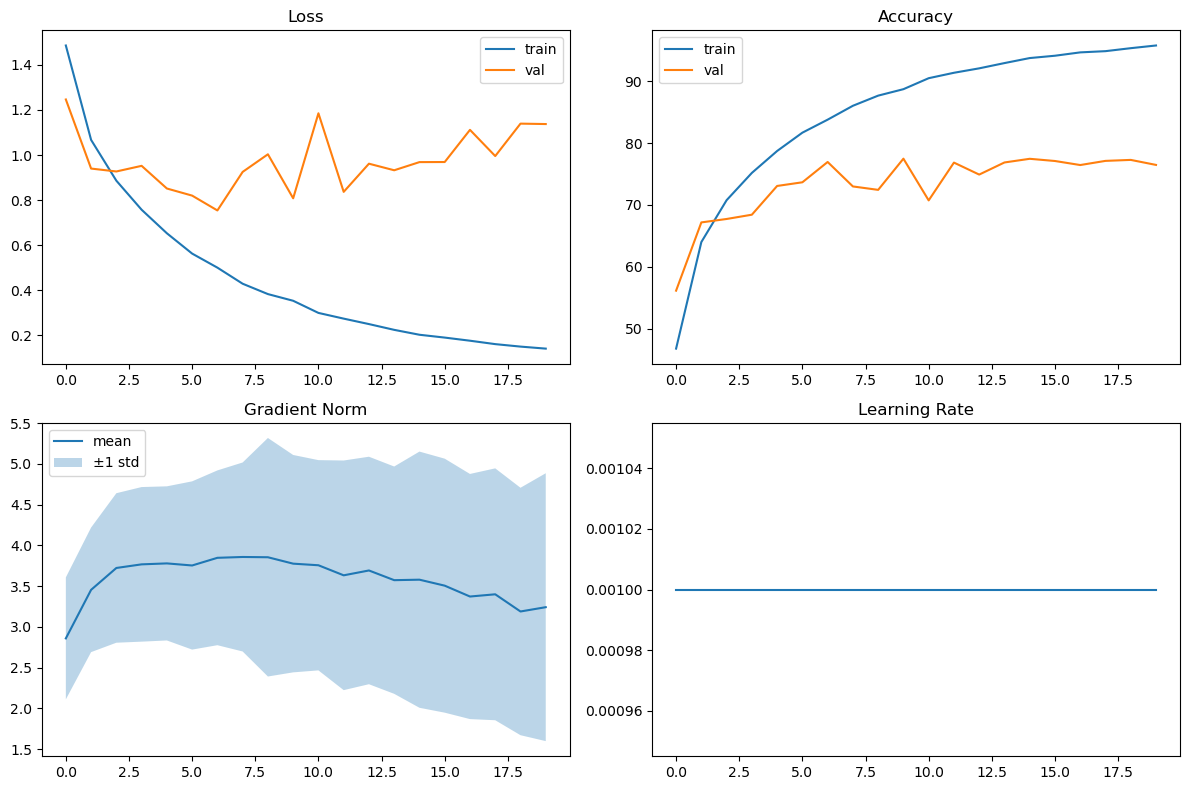

In [18]:
plot_training_results(vanilla_cnn_results["history"])

[Info] Learning may have plateaued around epoch 8


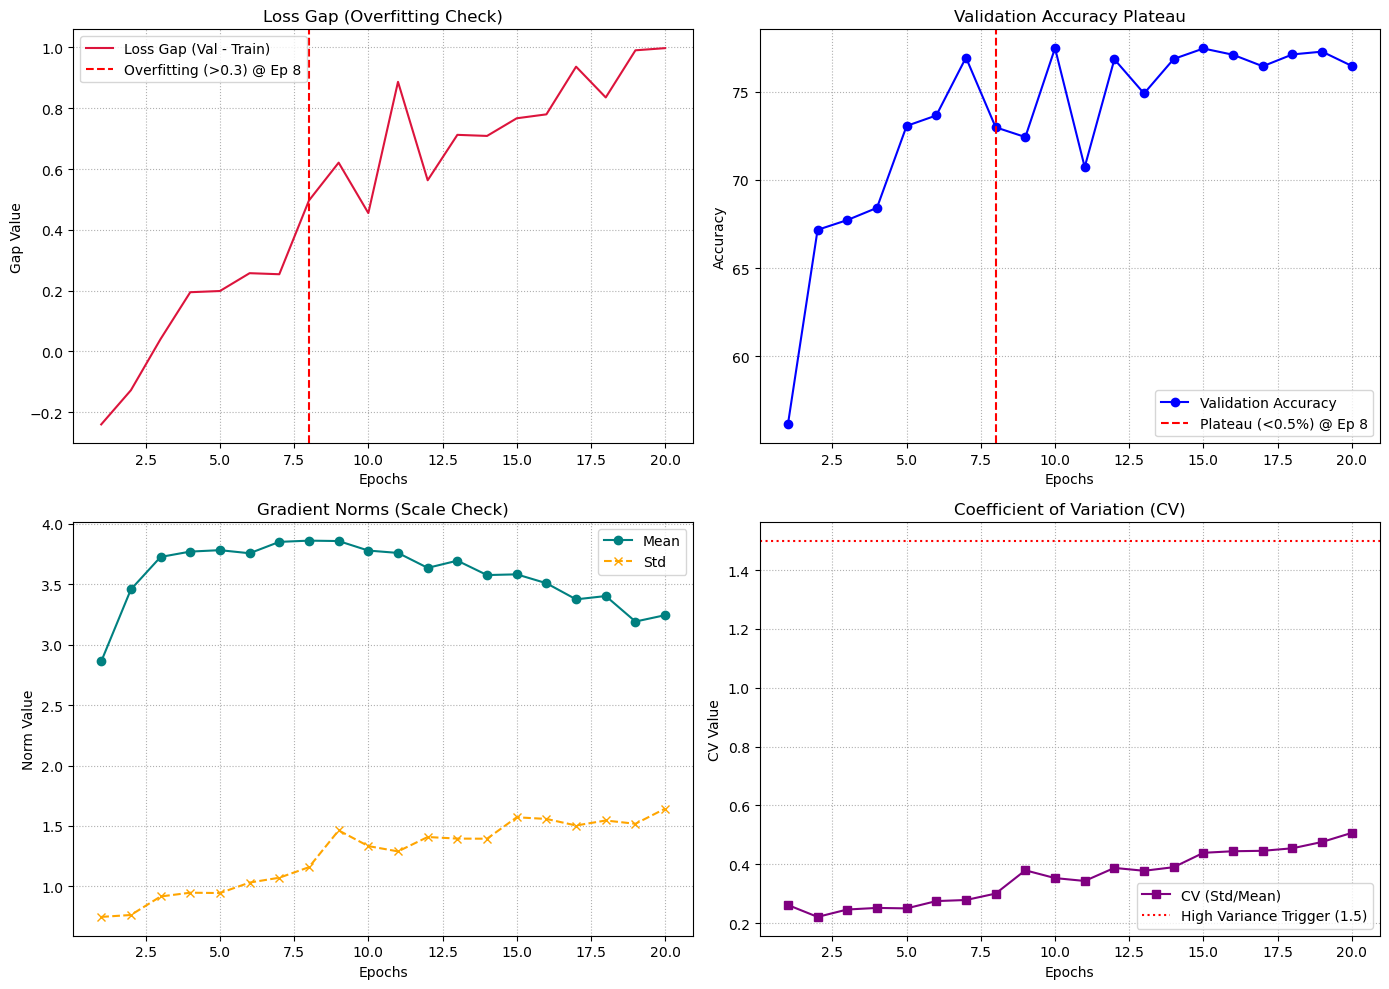

In [19]:
inspect_model(vanilla_cnn_results["history"])

### 1. ResNet

In [23]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes, planes, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = nn.Conv2d(
            planes, planes, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes, planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [26]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], 1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2)

        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = F.avg_pool2d(x, 4)
        x = x.view(x.size(0), -1)

        return self.fc(x)

In [27]:
def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

In [32]:
model = ResNet18().to("cpu")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [35]:
torch.onnx.export(model, torch.randn(1, 3, 32, 32), "resnet18.onnx", dynamo=False)

/var/folders/7j/k9zl0xqx2dld016qy5yygy8r0000gn/T/ipykernel_2731/2987101947.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 3, 32, 32), "resnet18.onnx", dynamo=False)


In [21]:
resnet18_results = train_model(
    model, 
    loss_fn,
    optimizer,
    train_loader,
    val_loader,
    epochs=20,
    scheduler=None,
    device=device,
)

Trainable Parameters: 11,173,962
Epoch 01 | train_loss: 1.373 | val_loss: 1.310 | train_acc: 49.7% | val_acc: 53.2% | grad_norm: 3.542 ± 1.046
Epoch 02 | train_loss: 0.877 | val_loss: 0.888 | train_acc: 68.9% | val_acc: 68.9% | grad_norm: 2.781 ± 0.609
Epoch 03 | train_loss: 0.659 | val_loss: 0.630 | train_acc: 76.9% | val_acc: 77.9% | grad_norm: 2.352 ± 0.498
Epoch 04 | train_loss: 0.522 | val_loss: 0.656 | train_acc: 81.9% | val_acc: 77.7% | grad_norm: 2.099 ± 0.495
Epoch 05 | train_loss: 0.412 | val_loss: 0.549 | train_acc: 85.7% | val_acc: 81.8% | grad_norm: 1.851 ± 0.425
Epoch 06 | train_loss: 0.319 | val_loss: 0.672 | train_acc: 88.8% | val_acc: 79.0% | grad_norm: 1.699 ± 0.403
Epoch 07 | train_loss: 0.235 | val_loss: 0.509 | train_acc: 91.7% | val_acc: 84.0% | grad_norm: 1.546 ± 0.394
Epoch 08 | train_loss: 0.168 | val_loss: 0.662 | train_acc: 94.0% | val_acc: 80.8% | grad_norm: 1.401 ± 0.531
Epoch 09 | train_loss: 0.136 | val_loss: 0.634 | train_acc: 95.1% | val_acc: 83.0% | gr

In [22]:
print(f"Best val acc : {resnet18_results['best_val_acc']:.2f}%  (epoch {resnet18_results['best_epoch']+1})")
print(f"Final val acc: {resnet18_results['history']['val_acc'][-1]:.2f}%")
print(f"Config       : {resnet18_results['config']}")

Best val acc : 84.49%  (epoch 19)
Final val acc: 82.38%
Config       : {'epochs': 20, 'lr': 0.001, 'batch_size': 64, 'optimizer': 'Adam', 'scheduler': None, 'parameters': 11173962}


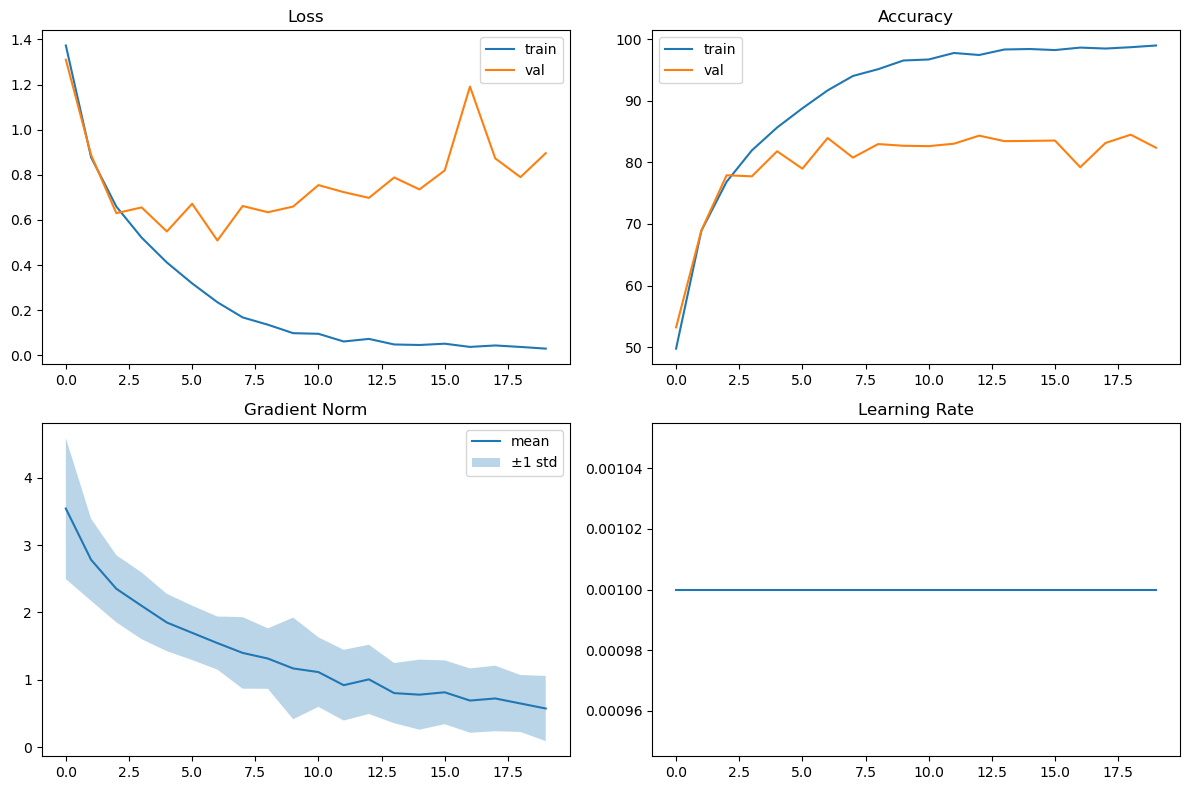

In [23]:
plot_training_results(resnet18_results["history"])

[Info] Learning may have plateaued around epoch 4


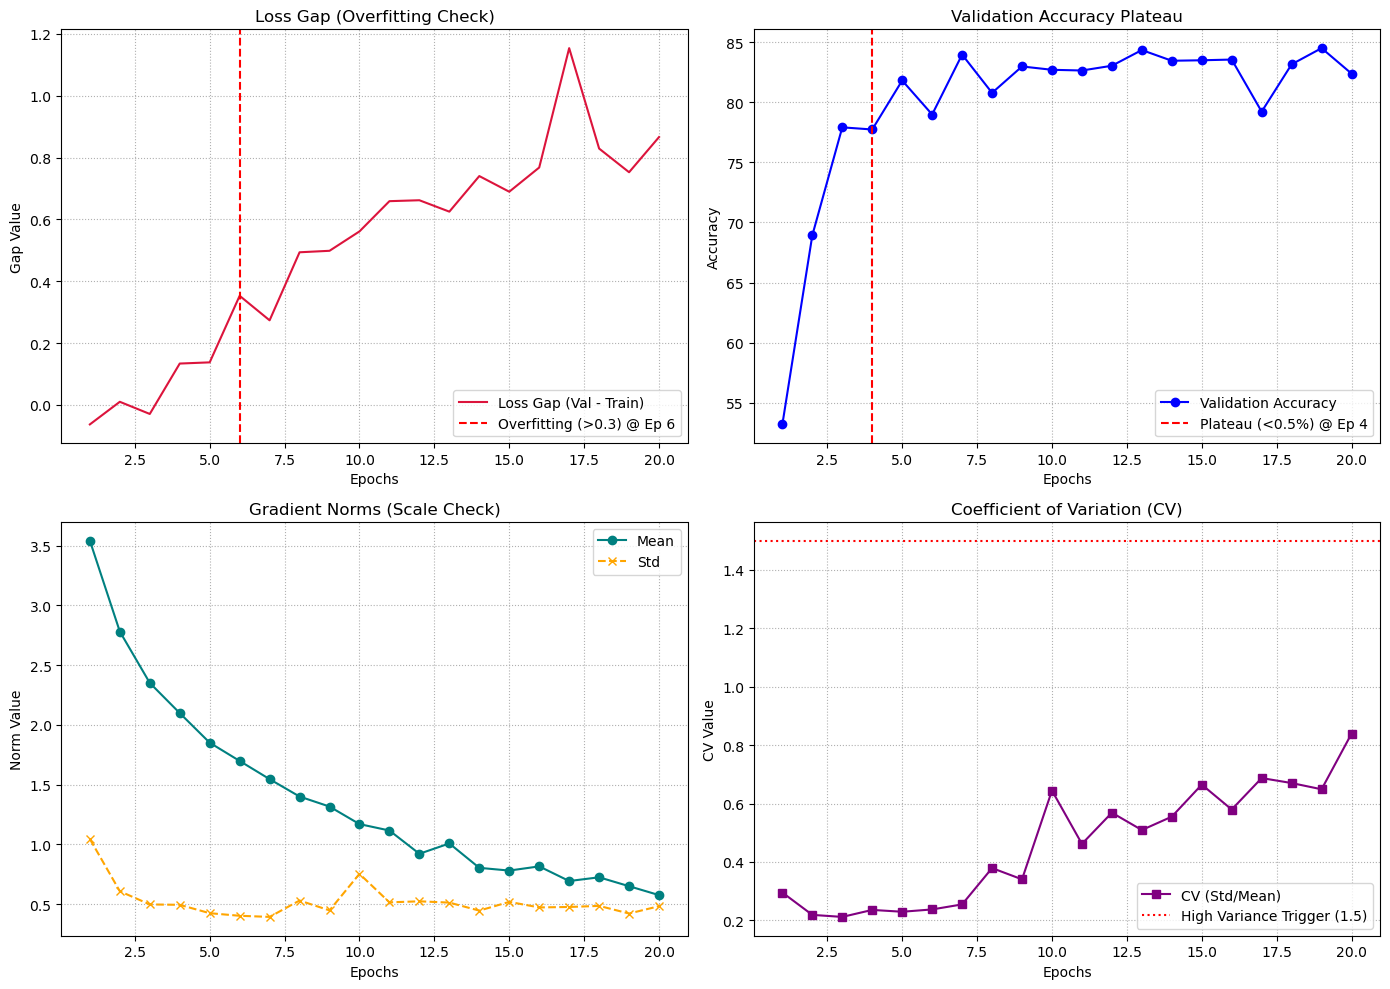

In [24]:
inspect_model(resnet18_results["history"])

### 3. DenseNet

In [4]:
class Bottleneck(nn.Module):
    def __init__(self,in_planes, growth_rate):
        super(Bottleneck, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, 4*growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4*growth_rate)
        self.conv2 = nn.Conv2d(4*growth_rate, growth_rate, kernel_size = 3, padding = 1, bias=False)

    def forward(self,x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        out = torch.cat([out,x],1)
        return out
class Transition(nn.Module):
    def __init__(self,in_planes, out_planes):
        super(Transition, self).__init__()
        self.bn = nn.BatchNorm2d(in_planes)
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size = 1, bias=False)

    def forward(self,x):
        out = self.conv(F.relu(self.bn(x)))
        out = F.avg_pool2d(out,2)
        return out

In [5]:
class DenseNet(nn.Module):
    def __init__(self, block, nblocks, growth_rate=12, reduction=0.5, num_classes=10):
        super(DenseNet, self).__init__()
        self.growth_rate = growth_rate

        num_planes = 2*growth_rate
        self.conv1 = nn.Conv2d(3, num_planes, kernel_size=3, padding=1, bias=False)

        self.dense1 = self._make_dense_layers(block, num_planes, nblocks[0])
        num_planes += nblocks[0]*growth_rate
        out_planes = int(math.floor(num_planes*reduction))
        self.trans1 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense2 = self._make_dense_layers(block, num_planes, nblocks[1])
        num_planes += nblocks[1]*growth_rate
        out_planes = int(math.floor(num_planes*reduction))
        self.trans2 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense3 = self._make_dense_layers(block, num_planes, nblocks[2])
        num_planes += nblocks[2]*growth_rate
        out_planes = int(math.floor(num_planes*reduction))
        self.trans3 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense4 = self._make_dense_layers(block, num_planes, nblocks[3])
        num_planes += nblocks[3]*growth_rate

        self.bn = nn.BatchNorm2d(num_planes)
        self.linear = nn.Linear(num_planes, num_classes)

    def _make_dense_layers(self, block, in_planes, nblock):
        layers = []
        for i in range(nblock):
            layers.append(block(in_planes, self.growth_rate))
            in_planes += self.growth_rate
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.trans1(self.dense1(out))
        out = self.trans2(self.dense2(out))
        out = self.trans3(self.dense3(out))
        out = self.dense4(out)
        out = F.avg_pool2d(F.relu(self.bn(out)), 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out
def DenseNet121():
    return DenseNet(Bottleneck, [6,12,24,16], growth_rate=32)


In [8]:

model = DenseNet121().to("cpu")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [14]:
def TinyDenseNet():
    return DenseNet(
        Bottleneck,
        [2, 2, 2, 2],
        growth_rate=12
    )

In [15]:
tinyModel = TinyDenseNet()


In [16]:
torch.onnx.export(tinyModel, torch.randn(1, 3, 32, 32), "tinydensenet.onnx", dynamo=False)

/var/folders/7j/k9zl0xqx2dld016qy5yygy8r0000gn/T/ipykernel_4652/1849628696.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(tinyModel, torch.randn(1, 3, 32, 32), "tinydensenet.onnx", dynamo=False)


In [9]:
torch.onnx.export(model, torch.randn(1, 3, 32, 32), "densenet.onnx", dynamo=False)

/var/folders/7j/k9zl0xqx2dld016qy5yygy8r0000gn/T/ipykernel_4652/208195936.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 3, 32, 32), "densenet.onnx", dynamo=False)


In [7]:
densenet_results = train_model(model,loss_fn, optimizer, train_loader, val_loader, epochs=20, device=device)

Trainable Parameters: 6,956,298
Epoch 01 | train_loss: 1.328 | val_loss: 1.202 | train_acc: 51.5% | val_acc: 58.7% | grad_norm: 2.635 ± 0.628
Epoch 02 | train_loss: 0.852 | val_loss: 0.774 | train_acc: 69.9% | val_acc: 72.8% | grad_norm: 2.192 ± 0.434
Epoch 03 | train_loss: 0.650 | val_loss: 0.680 | train_acc: 77.1% | val_acc: 76.3% | grad_norm: 1.935 ± 0.405
Epoch 04 | train_loss: 0.516 | val_loss: 0.560 | train_acc: 81.9% | val_acc: 80.8% | grad_norm: 1.778 ± 0.361
Epoch 05 | train_loss: 0.424 | val_loss: 0.451 | train_acc: 85.2% | val_acc: 84.3% | grad_norm: 1.617 ± 0.354
Epoch 06 | train_loss: 0.354 | val_loss: 0.457 | train_acc: 87.7% | val_acc: 84.4% | grad_norm: 1.521 ± 0.340
Epoch 07 | train_loss: 0.290 | val_loss: 0.499 | train_acc: 90.0% | val_acc: 83.1% | grad_norm: 1.420 ± 0.341
Epoch 08 | train_loss: 0.235 | val_loss: 0.439 | train_acc: 91.6% | val_acc: 85.4% | grad_norm: 1.357 ± 0.344
Epoch 09 | train_loss: 0.198 | val_loss: 0.514 | train_acc: 93.0% | val_acc: 83.7% | gra

In [10]:
print(f"Best val acc : {densenet_results['best_val_acc']:.2f}%  (epoch {densenet_results['best_epoch']+1})")
print(f"Final val acc: {densenet_results['history']['val_acc'][-1]:.2f}%")
print(f"Config       : {densenet_results['config']}")

Best val acc : 88.15%  (epoch 16)
Final val acc: 87.50%
Config       : {'epochs': 20, 'lr': 0.001, 'batch_size': 64, 'optimizer': 'Adam', 'scheduler': None, 'parameters': 6956298}


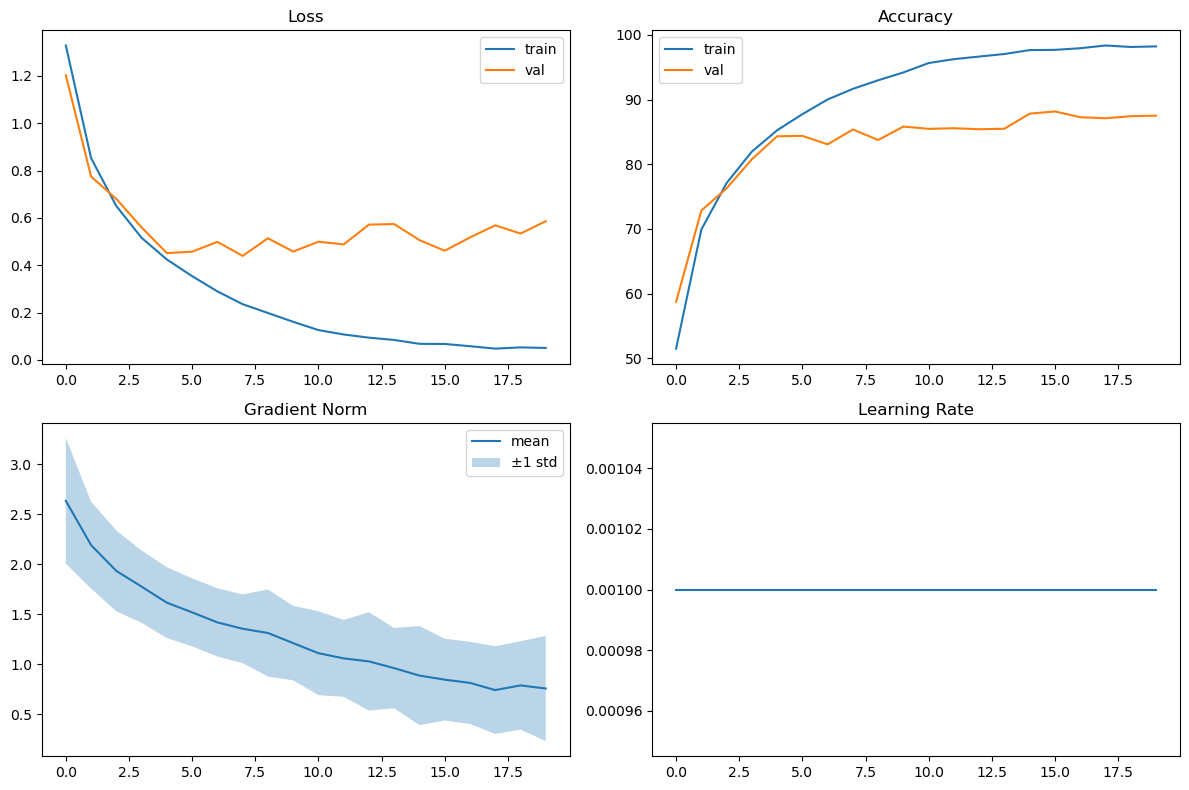

In [8]:
plot_training_results(densenet_results["history"])

[Info] Learning may have plateaued around epoch 7


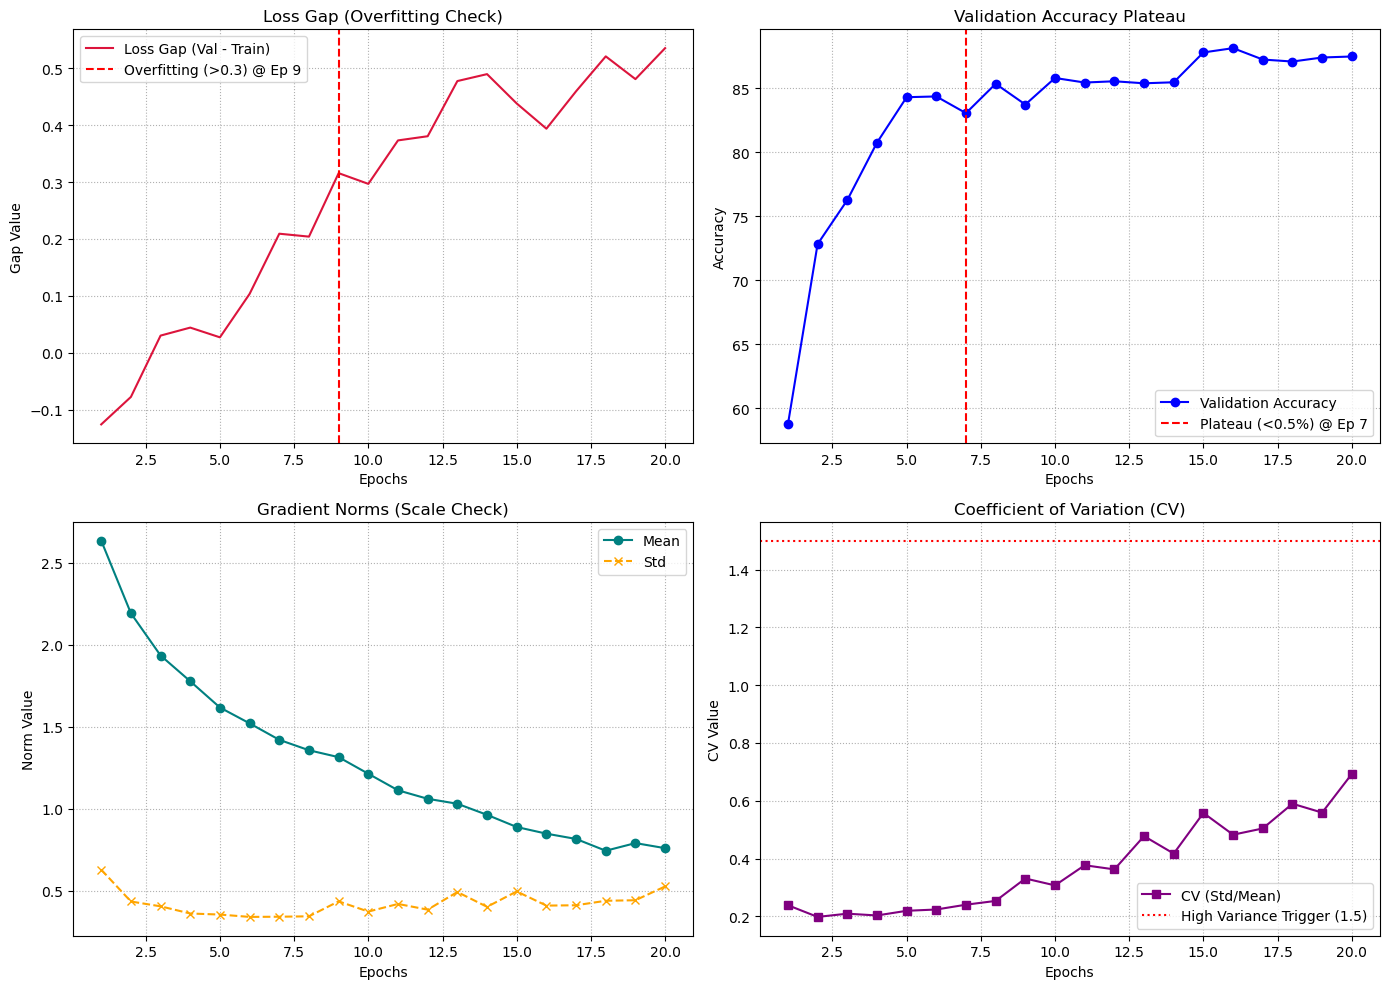

In [9]:
inspect_model(densenet_results["history"])

### 4. DLA

In [2]:
'''DLA in PyTorch.

Reference:
    Deep Layer Aggregation. https://arxiv.org/abs/1707.06484
'''



class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class Root(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1):
        super(Root, self).__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size,
            stride=1, padding=(kernel_size - 1) // 2, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, xs):
        x = torch.cat(xs, 1)
        out = F.relu(self.bn(self.conv(x)))
        return out


class Tree(nn.Module):
    def __init__(self, block, in_channels, out_channels, level=1, stride=1):
        super(Tree, self).__init__()
        self.level = level
        if level == 1:
            self.root = Root(2*out_channels, out_channels)
            self.left_node = block(in_channels, out_channels, stride=stride)
            self.right_node = block(out_channels, out_channels, stride=1)
        else:
            self.root = Root((level+2)*out_channels, out_channels)
            for i in reversed(range(1, level)):
                subtree = Tree(block, in_channels, out_channels,
                               level=i, stride=stride)
                self.__setattr__('level_%d' % i, subtree)
            self.prev_root = block(in_channels, out_channels, stride=stride)
            self.left_node = block(out_channels, out_channels, stride=1)
            self.right_node = block(out_channels, out_channels, stride=1)

    def forward(self, x):
        xs = [self.prev_root(x)] if self.level > 1 else []
        for i in reversed(range(1, self.level)):
            level_i = self.__getattr__('level_%d' % i)
            x = level_i(x)
            xs.append(x)
        x = self.left_node(x)
        xs.append(x)
        x = self.right_node(x)
        xs.append(x)
        out = self.root(xs)
        return out


class DLA(nn.Module):
    def __init__(self, block=BasicBlock, num_classes=10):
        super(DLA, self).__init__()
        self.base = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(True)
        )

        self.layer1 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(True)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True)
        )

        self.layer3 = Tree(block,  32,  64, level=1, stride=1)
        self.layer4 = Tree(block,  64, 128, level=2, stride=2)
        self.layer5 = Tree(block, 128, 256, level=2, stride=2)
        self.layer6 = Tree(block, 256, 512, level=1, stride=2)
        self.linear = nn.Linear(512, num_classes)

    def forward(self, x):
        out = self.base(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def test():
    net = DLA()
    print(net)
    x = torch.randn(1, 3, 32, 32)
    y = net(x)
    print(y.size())



In [5]:
model = DLA().to("cpu")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [4]:
torch.onnx.export(model, torch.randn(1, 3, 32, 32), "dla.onnx", dynamo=False)

/var/folders/7j/k9zl0xqx2dld016qy5yygy8r0000gn/T/ipykernel_1728/3054931205.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 3, 32, 32), "dla.onnx", dynamo=False)


In [13]:
dla_results = train_model(model,loss_fn, optimizer, train_loader, val_loader, epochs=20, device=device)

Trainable Parameters: 16,291,386
Epoch 01 | train_loss: 1.488 | val_loss: 1.153 | train_acc: 45.2% | val_acc: 58.2% | grad_norm: 3.192 ± 1.018
Epoch 02 | train_loss: 0.983 | val_loss: 0.945 | train_acc: 64.8% | val_acc: 65.4% | grad_norm: 2.897 ± 0.693
Epoch 03 | train_loss: 0.765 | val_loss: 0.784 | train_acc: 73.0% | val_acc: 72.6% | grad_norm: 2.610 ± 0.568
Epoch 04 | train_loss: 0.617 | val_loss: 0.628 | train_acc: 78.3% | val_acc: 78.1% | grad_norm: 2.325 ± 0.495
Epoch 05 | train_loss: 0.508 | val_loss: 0.655 | train_acc: 82.4% | val_acc: 77.6% | grad_norm: 2.223 ± 0.470
Epoch 06 | train_loss: 0.420 | val_loss: 0.610 | train_acc: 85.5% | val_acc: 79.0% | grad_norm: 2.104 ± 0.559
Epoch 07 | train_loss: 0.339 | val_loss: 0.587 | train_acc: 88.2% | val_acc: 80.1% | grad_norm: 1.980 ± 0.486
Epoch 08 | train_loss: 0.273 | val_loss: 0.543 | train_acc: 90.4% | val_acc: 82.9% | grad_norm: 1.895 ± 0.501
Epoch 09 | train_loss: 0.203 | val_loss: 0.638 | train_acc: 92.8% | val_acc: 80.9% | gr

In [16]:
print(f"Best val acc : {dla_results['best_val_acc']:.2f}%  (epoch {dla_results['best_epoch']+1})")
print(f"Final val acc: {dla_results['history']['val_acc'][-1]:.2f}%")
print(f"Config       : {dla_results['config']}")

Best val acc : 82.89%  (epoch 8)
Final val acc: 82.56%
Config       : {'epochs': 20, 'lr': 0.001, 'batch_size': 64, 'optimizer': 'Adam', 'scheduler': None, 'parameters': 16291386}


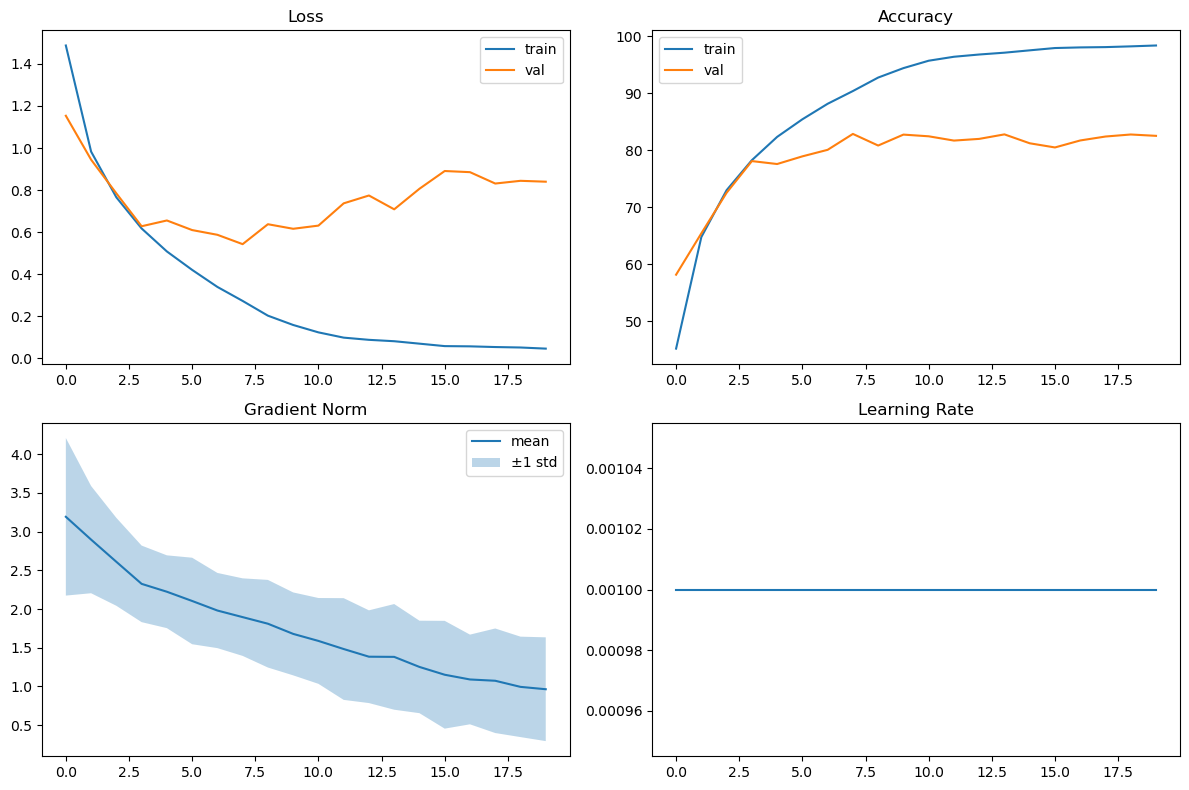

In [14]:
plot_training_results(dla_results["history"])

[Info] Learning may have plateaued around epoch 5


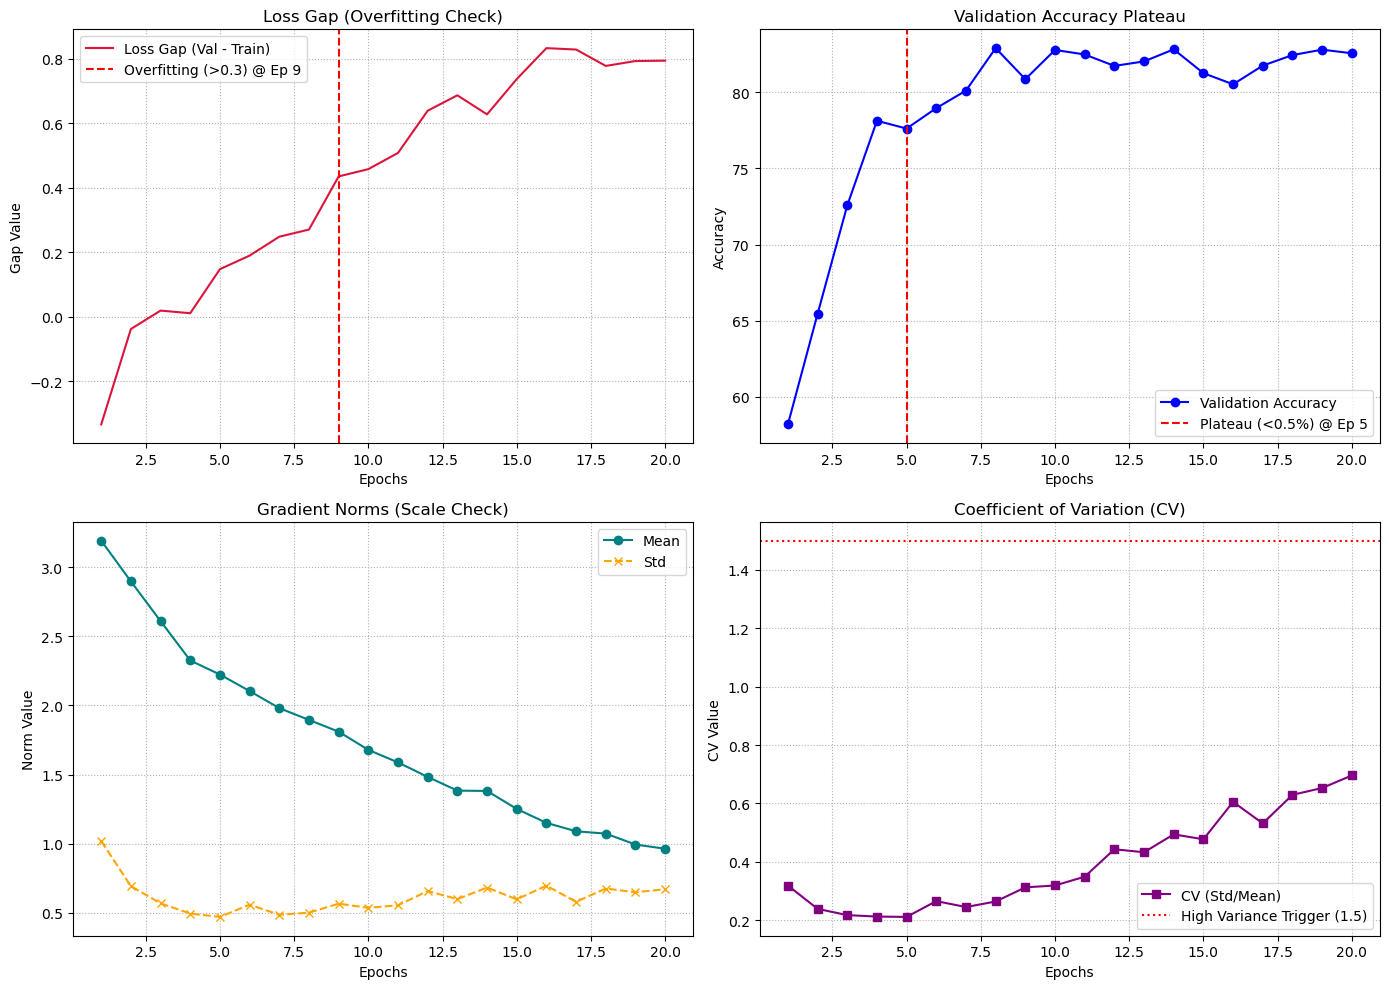

In [15]:
inspect_model(dla_results["history"])